<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/Titanic2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report, roc_auc_score,roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
pd.DataFrame({'data_type':df.dtypes,'unique_values':df.nunique()})

,data_type,unique_values
PassengerId,int64,891
Survived,int64,2
Pclass,int64,3
Name,object,891
Sex,object,2
Age,float64,88
SibSp,int64,7
Parch,int64,7
Ticket,object,681
Fare,float64,248


In [6]:
df.drop(['PassengerId','Cabin','Name'],axis=1,inplace=True)

In [7]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [9]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [10]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [12]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [13]:
pd.DataFrame({'data_types':df.dtypes,'unique_values':df.nunique()})

,data_types,unique_values
Survived,int64,2
Pclass,int64,3
Sex,object,2
Age,float64,89
SibSp,int64,7
Parch,int64,7
Ticket,object,681
Fare,float64,248
Embarked,object,3


In [14]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


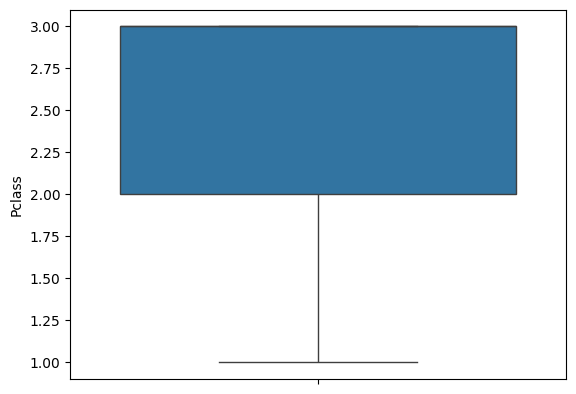

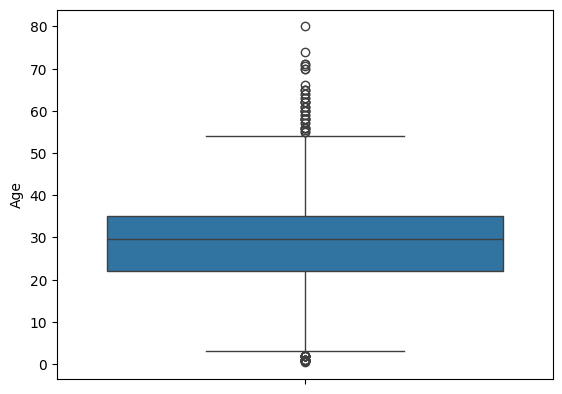

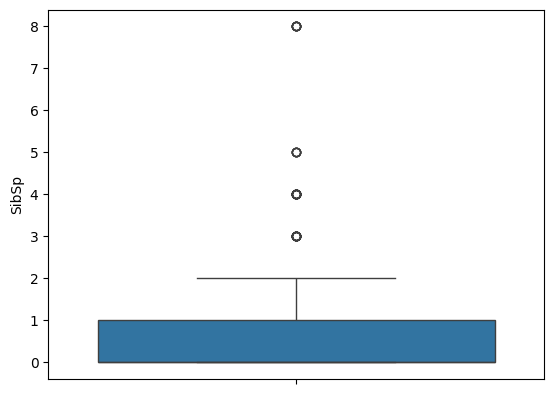

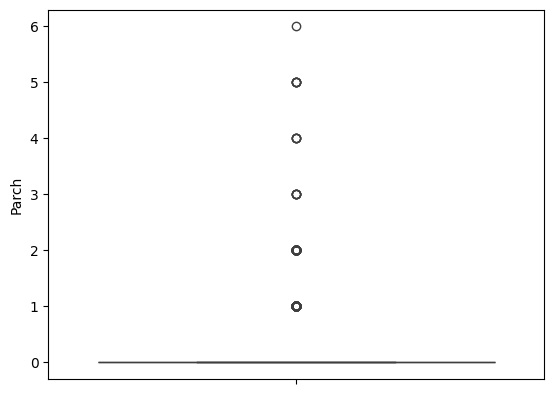

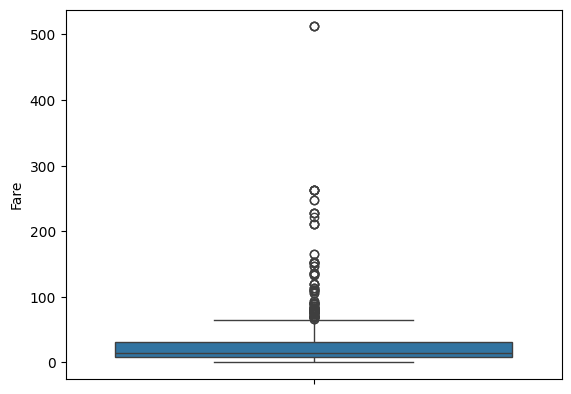

In [15]:
s=['Pclass','Age','SibSp','Parch','Fare']

for i in s:
  sns.boxplot(df[i])
  plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [17]:
df['Age'].min()

0.42

In [18]:
num=df[['Pclass','Age','SibSp','Parch','Fare']]
Q1=num.quantile(0.25)
Q3=num.quantile(0.75)

IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)

lower_outliers=num<lower_bound
upper_outliers=num>upper_bound

In [19]:
print(lower_bound)

Pclass     0.500
Age        2.500
SibSp     -1.500
Parch      0.000
Fare     -26.724
dtype: float64


In [20]:
print(lower_outliers.sum())

Pclass     0
Age       24
SibSp      0
Parch      0
Fare       0
dtype: int64


In [21]:
print(upper_outliers.sum())

Pclass      0
Age        42
SibSp      46
Parch     213
Fare      116
dtype: int64


In [22]:
# s = ['Age', 'SibSp', 'Parch', 'Fare']

# for i in s:
#     lb = lower_bound[i]
#     ub = upper_bound[i]
#     df[i] = df[i].clip(lower=lb, upper=ub)

In [23]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
df.drop(['Ticket'],axis=1,inplace=True)

In [25]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [26]:
s=['Sex','Embarked']
for i in s:
  print(df[i].value_counts(),'\n')

Sex
male      577
female    314
Name: count, dtype: int64 

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64 



In [27]:
df.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


In [28]:
df['Sex']=df['Sex'].map({'male':1,'female':0})

In [29]:
df['Sex'].value_counts()

,count
Sex,
1,577
0,314


In [30]:
df=pd.get_dummies(df,columns=['Embarked'], drop_first=True)

In [31]:
X=df.drop(['Survived'],axis=1)
y=df['Survived']

In [32]:
sc=StandardScaler()
X_Scaled=sc.fit_transform(X)

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X_Scaled,y,test_size=0.2,random_state=1,stratify=y)

In [34]:
y_train.value_counts()

,count
Survived,
0,439
1,273


In [35]:
y_test.value_counts()

,count
Survived,
0,110
1,69


In [36]:
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

In [37]:
y_pred_train=lg.predict(X_train)
y_pred_test=lg.predict(X_test)

In [38]:
accuracy_score(y_test,y_pred_test)

0.7932960893854749

In [39]:
accuracy_score(y_train,y_pred_train)

0.8033707865168539

In [40]:
cross_val_score(lg,X_train,y_train,cv=10).mean()

np.float64(0.7977112676056338)


    key rules for kfold cv:
    Agar train_acc.mean() ≫ test_acc → model may be overfitting
	•	Agar train_acc.mean() ≪ test_acc → kuch gadbad! (maybe data leakage?)
	•	Agar dono similar → 🎯 well-trained model

    train_accuracy mean: 0.7949334898278562

    normal test accuracy: 0.7932960893854749

    hence: we can that it is well trained model

In [41]:
print('\n',classification_report(y_test,y_pred_test))


               precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [42]:
X_train.shape

(712, 8)

ROC: 0.836034255599473 



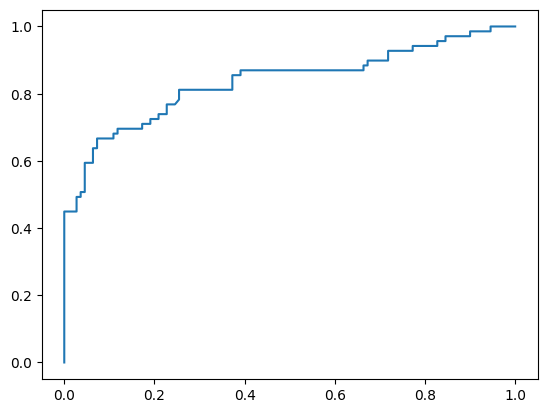

In [43]:
y_probs = lg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)
print('ROC:',roc_auc,'\n')
plt.plot(fpr, tpr)
plt.show()

In [44]:
roc_curve(y_test, y_probs)

(array([0.        , 0.        , 0.        , 0.02727273, 0.02727273,
        0.03636364, 0.03636364, 0.04545455, 0.04545455, 0.04545455,
        0.06363636, 0.06363636, 0.07272727, 0.07272727, 0.10909091,
        0.10909091, 0.11818182, 0.11818182, 0.17272727, 0.17272727,
        0.19090909, 0.19090909, 0.20909091, 0.20909091, 0.22727273,
        0.22727273, 0.24545455, 0.25454545, 0.25454545, 0.3       ,
        0.32727273, 0.37272727, 0.37272727, 0.39090909, 0.39090909,
        0.46363636, 0.49090909, 0.54545455, 0.56363636, 0.66363636,
        0.66363636, 0.67272727, 0.67272727, 0.71818182, 0.71818182,
        0.73636364, 0.75454545, 0.77272727, 0.77272727, 0.8       ,
        0.82727273, 0.82727273, 0.84545455, 0.84545455, 0.9       ,
        0.9       , 0.94545455, 0.94545455, 1.        ]),
 array([0.        , 0.01449275, 0.44927536, 0.44927536, 0.49275362,
        0.49275362, 0.50724638, 0.50724638, 0.53623188, 0.5942029 ,
        0.5942029 , 0.63768116, 0.63768116, 0.66666667, 0.

In [45]:
lg.predict_proba(X_test)[:1]

array([[0.91685664, 0.08314336]])

	•	0.91145017 → probability that this person did NOT survive (class 0)
	•	0.08854983 → probability that this person DID survive (class 1)

In [46]:
lg.predict_proba(X_test)[:,1]

array([0.08314336, 0.25249371, 0.23117052, 0.35769183, 0.10595591,
       0.12538325, 0.07801777, 0.46395498, 0.32364128, 0.12743744,
       0.87804752, 0.56045265, 0.49601586, 0.0675864 , 0.9761492 ,
       0.1112533 , 0.13414635, 0.79922401, 0.76700108, 0.32364128,
       0.12288399, 0.09834683, 0.92203029, 0.0385465 , 0.11294433,
       0.10469749, 0.78253583, 0.7061943 , 0.08790751, 0.17207321,
       0.08875577, 0.15846546, 0.7349416 , 0.80218724, 0.08883522,
       0.68894197, 0.00407138, 0.10213291, 0.55560503, 0.11028933,
       0.12752995, 0.66161882, 0.08871342, 0.06440129, 0.80879848,
       0.85008287, 0.94895366, 0.14721497, 0.14562137, 0.69610338,
       0.10210822, 0.13396565, 0.06390046, 0.59714241, 0.05182052,
       0.05318551, 0.72087135, 0.97154116, 0.33928217, 0.69610338,
       0.13414635, 0.49097303, 0.65262804, 0.09470938, 0.77688119,
       0.12613998, 0.87903674, 0.50736219, 0.7775627 , 0.38001129,
       0.91564617, 0.80305284, 0.23117052, 0.48155045, 0.80280

In [47]:
y_pred_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0])

    predict proba k andar pehle prediction probalities store hoti h by
    lg.predict_proba(X_test)
    lg.predict(X_test) se 0 aur 1 me wo classify ho jaata h

    phir usko threshold default:0.5 k basis pr 0 ya 1 class me classify kiya jaata h

    Medical field me galti ki gunjaish kam rakhni hai,
    isliye threshold kam (e.g. 0.3 ya 0.4) rakh sakte hoon taaki false negative pakad me aaye
    threshold customize bhi kr skte h apne hisab se, taaki predictions accurate ho

    Best Practice in Medical AI:
	•	Low threshold = High Recall (Sensitivity)
    “Jitne bhi cancer ke suspects hain, sabko pakdo”
	•	Phir specialist confirm karega final result

In [56]:
y_prob_test = lg.predict_proba(X_test)[:, 1]
threshold = 0.3
y_pred_c_test = (y_prob_test >= threshold).astype(int)

In [60]:
y_prob_train = lg.predict_proba(X_train)[:, 1]
threshold = 0.3
y_pred_c_train = (y_prob_train >= threshold).astype(int)

In [49]:
print(classification_report(y_test,y_pred_c_test))

              precision    recall  f1-score   support

           0       0.86      0.75      0.80       110
           1       0.67      0.81      0.73        69

    accuracy                           0.77       179
   macro avg       0.76      0.78      0.77       179
weighted avg       0.79      0.77      0.77       179



In [50]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [61]:
accuracy_score(y_train,y_pred_c_train)

0.7780898876404494

In [51]:
accuracy_score(y_test,y_pred_custom)

0.770949720670391

In [52]:
accuracy_score(y_test,y_pred_test)

0.7932960893854749

In [62]:
accuracy_score(y_train,y_pred_train)

0.8033707865168539

In [53]:
print(confusion_matrix(y_test,y_pred_custom))

[[82 28]
 [13 56]]
